In [2]:
import os
 
import torch
from torch.utils.data import Dataset, DataLoader  # Pytorch의 데이터셋 관련
from torchvision import transforms  # 전처리모듈

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

from lxml import etree

In [7]:
trainlist = [x for x in os.listdir('./data/Astrophysics/') if x.endswith('jpg')]
len(trainlist)

2529

In [10]:
testlist = [x for x in os.listdir('./data/testData/') if x.endswith('png')]
len(testlist)

680

In [30]:
for i in testlist:
    tree = etree.parse(f'./data/Annotation/Eval/Label/Pascal/AstroPhysics/{i[:-4]}.xml')
    root = tree.getroot()
    for i in root.findall('object'):
        label = i.find('name').text
        print(i.find('object')) 
    break

None


In [76]:
DATA_DIR = './data/Astrophysics'
## 1920 * 1080
## 640 * 360
transform = transforms.Compose(
    [   
        transforms.Resize((360,640)),
        transforms.PILToTensor(),  ## PIL.ToTensor 사용 ToTensor와는 다름.
                                    ## PIL의 Image 객체를 텐서화
        transforms.ConvertImageDtype(dtype=torch.float)  ## Image 텐서 타입 설정
    ]
    
)


In [77]:
## stasndard class x_rayDataset(Dataset):
class x_rayDataset(Dataset):
    def __init__(self, image_root, xml_root, transform=None):
        super().__init__()
        self.image_root = image_root
        self.xml_root = xml_root
        self.transform = transform

        self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
        self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
        self.class2idx["unknown"] = 0

        self.data = self._load_metadata()  # 이미지 경로와 XML 경로만 저장

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path, xml_path = self.data[index]
        image = Image.open(img_path).convert("RGB")

        # XML 파싱
        boxes, labels = [], []
        tree = etree.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall('object'):
            label = obj.find('name').text
            label = label if label in self.flist else "unknown"
            bbox = obj.find('bndbox')
            # xmin = int(bbox.find('xmin').text)
            # ymin = int(bbox.find('ymin').text)
            # xmax = int(bbox.find('xmax').text)
            # ymax = int(bbox.find('ymax').text)
            xmin = int(bbox.find('xmin').text)//3
            ymin = int(bbox.find('ymin').text)//3
            xmax = int(bbox.find('xmax').text)//3
            ymax = int(bbox.find('ymax').text)//3
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class2idx[label])

        target = {
            "boxes": torch.FloatTensor(boxes),
            "labels": torch.LongTensor(labels)
        }

        if self.transform:
            image = self.transform(image)

        return image, target

    def _load_metadata(self):
        data = []
        for filenames in os.listdir(self.image_root):
            if not filenames.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(self.image_root, filenames)
            xml_path = os.path.join(self.xml_root, filenames[:-4] + ".xml")

            # if not os.path.exists(xml_path):
            #     continue  # 해당 XML이 없으면 스킵

            data.append((img_path, xml_path))
            # print(data)
        return data


In [78]:
trainDS = x_rayDataset(
    image_root='./data/Astrophysics/',
    ## train image 경로
    xml_root=r"./data/Annotation/Pascal/Astrophysics/",
    ## train xml 경로
    transform=transform
)
validDS = x_rayDataset(
    image_root='./data/testData/',
    ## test image 경로
    xml_root=r"./data/Annotation/Eval/Label/Pascal/AstroPhysics/",
    ## test xml 경로
    transform=transform
)



In [79]:
# # img, target = trainDS[0]
# print(len(img), target)

print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[validDS] 개수  : {len(validDS)}개 ')

[trainDS] 개수 : 2529개 
[validDS] 개수  : 680개 


In [80]:
## 배치 데이터 생성 함수
## ---------------------------------------------------------
## 함수기능 : 개별 샘플을 미니배치로 결합하는 역할
## 함수이름 : collator
## 매개변수 : 배치크기
## 반환결과 : 배치크기만큼 연결된 데이터
## ---------------------------------------------------------
def collator(batch):
    return tuple(zip(*batch))

In [81]:
## 클래스 변환 Dict 생성
idx2class ={value:key for key, value in trainDS.class2idx.items()}
IDX_TO_CATEGORY = idx2class
print(IDX_TO_CATEGORY)
## 학습용 테스트용 데이터 확인
print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[validDS] 개수  : {len(validDS)}개 ')
## 학습용 데이터셋에서 이미지 1개
imgTS, targetDict = trainDS[0]  ## <== __getitem__(indx)
print(imgTS.shape, targetDict.keys())

{1: 'Firecracker', 2: 'Hammer', 3: 'NailClippers', 4: 'Spanner', 5: 'Thinner', 6: 'ZippoOil', 0: 'unknown'}
[trainDS] 개수 : 2529개 
[validDS] 개수  : 680개 
torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])


torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])


lx, ly, w, h => (283, 132, 125, 112)


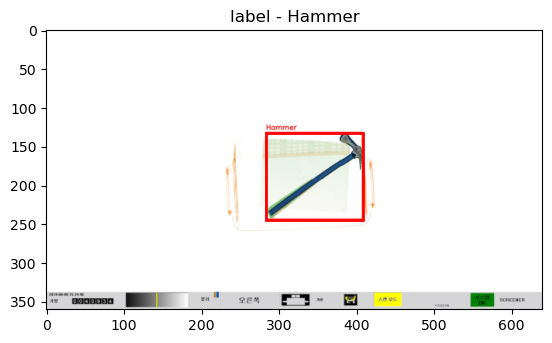

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (270, 135, 133, 93)


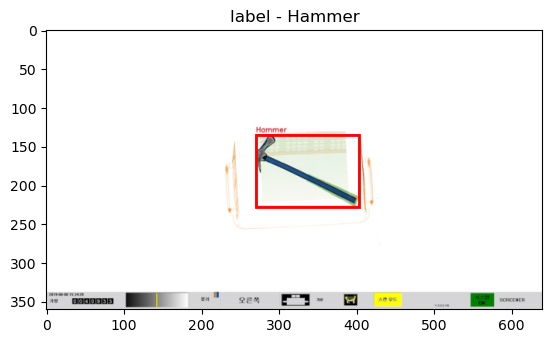

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (249, 177, 144, 56)


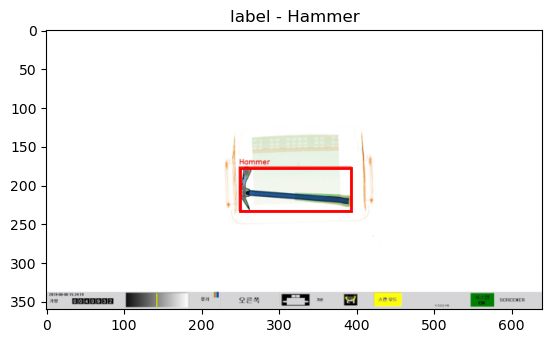

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (299, 94, 60, 141)


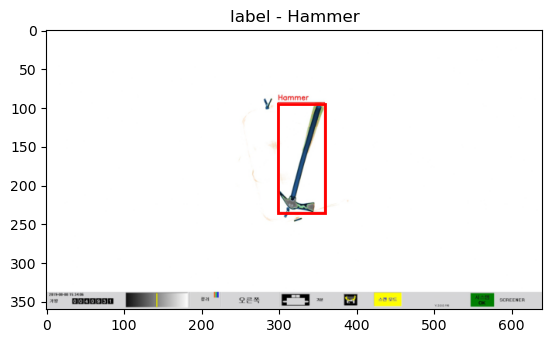

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (251, 163, 143, 75)


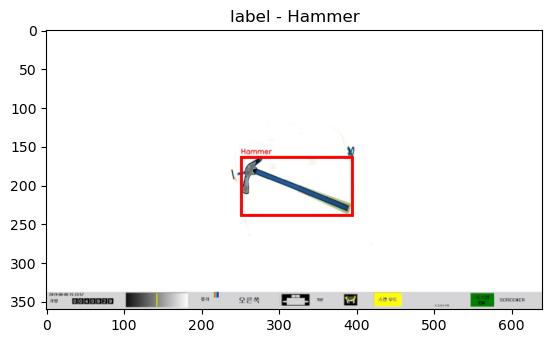

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (252, 100, 82, 136)


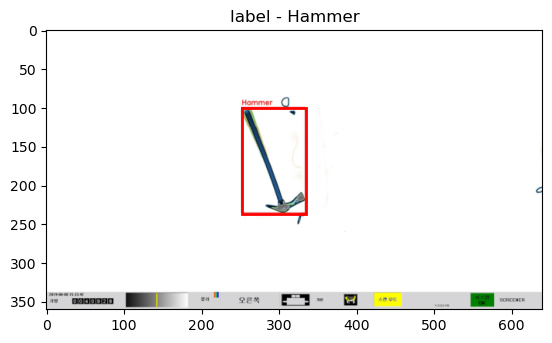

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (263, 116, 120, 109)


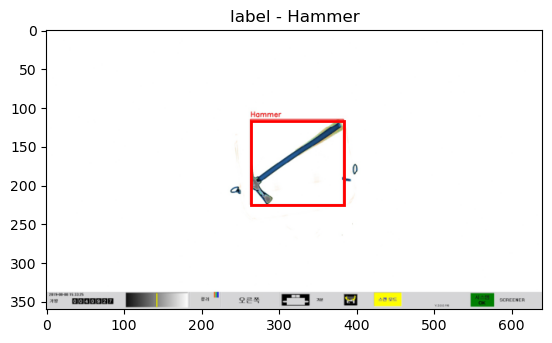

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (357, 87, 96, 119)


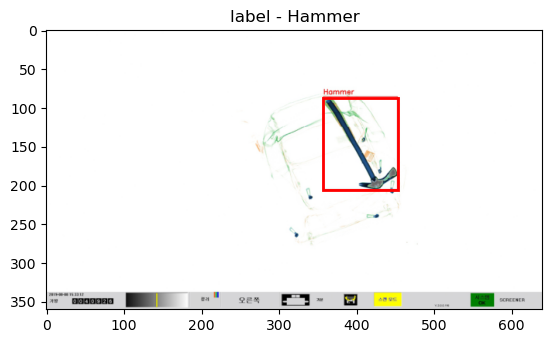

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (299, 155, 143, 58)


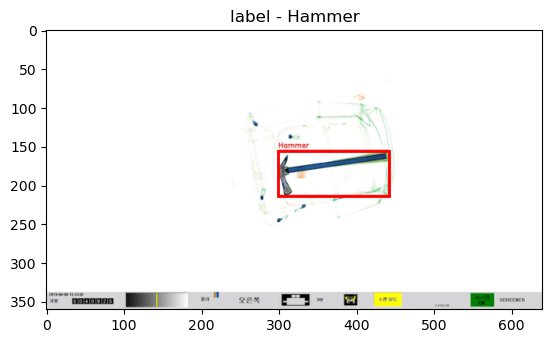

torch.Size([3, 360, 640]) dict_keys(['boxes', 'labels'])
lx, ly, w, h => (321, 114, 89, 134)


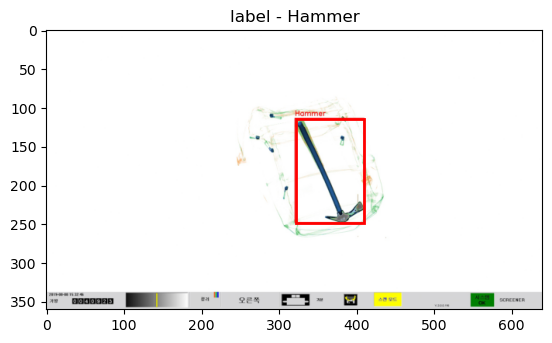

In [82]:

for i in range(1210, 1220):
    imgTS, targetDict = trainDS[i]  ## <== __getitem__(indx)
    print(imgTS.shape, targetDict.keys())
    # - 라벨 정보 추출
    label = targetDict['labels'].item()

    # - 객체 위치 정보 추출
    lx, ly, rx, ry = [round(data.item()) for data in targetDict['boxes'].reshape(-1)]
    w, h = rx - lx, ry - ly

    print(f'lx, ly, w, h => {lx, ly, w, h}')
    ## 시각화 및 바운딩 박스
    plt.imshow(imgTS.permute(1, 2, 0))
    plt.title(f'label - {IDX_TO_CATEGORY[label]}')

    ## 바운딩 박스 추가
    ax = plt.gca()  #- get current axis
    ax.add_patch(patches.Rectangle((lx, ly), w, h, color='red', linewidth=2, fill=False))

    plt.show()